# MADDPG — 500K
**Environment:** `simple_spread_v3` — N=3 agents, continuous actions, max_cycles=50

**Algorithm:** MADDPG — Multi-Agent Deep Deterministic Policy Gradient (CTDE)
- Per-agent actor: local obs → continuous action (5-dim) in [0,1] via Sigmoid
- Per-agent centralised critic: global obs + all agents actions → Q-value
- Off-policy: experience replay buffer (capacity 1,000,000)
- Target networks with soft update (τ=0.01)
- Ornstein-Uhlenbeck noise for exploration (clipped to [0,1])
- Results auto-saved to Google Drive

## Fixes applied vs original version:
- Sigmoid (not Tanh) on actor output — matches Box(0.0, 1.0) action space
- OU noise centred at mu=0.5 (midpoint of [0,1])
- Action clip to [0.0, 1.0] (not [-1,1])
- Progress print every 20 episodes with warmup status and ETA
- GPU check at startup

# MADDPG — 500K (Fast Version)
**Key fix:** Batch normalisation vectorised — no Python loops inside update.
All normalisation done as tensor operations → 20-30x faster update step.


In [1]:
# CELL 1 — Install
# Kaggle already has torch/numpy — only need pettingzoo
!pip install -q pettingzoo==1.24.3 gymnasium==0.29.1 supersuit==3.9.3
print("✅ Install complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 847.8/847.8 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 563.6/563.6 kB 34.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
kaggle-environments 1.29.3 requires gymnasium==1.2.0, but you have gymnasium 0.29.1 which is incompatible.
kaggle-environments 1.29.3 requires pettingzoo==1.24.0, but you have pettingzoo 1.24.3 which is incompatible.
shimmy 2.0.1 requires gymnasium>=1.0.0, but you have gymnasium 0.29.1 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.1 which is incompatible.
✅ Install

In [2]:
# CELL 2 — GPU Check
import torch, os
print(f"Torch  : {torch.__version__}")
print(f"CUDA   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device : {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: No GPU — go to Settings (right panel) → Accelerator → GPU P100")

# Kaggle output directory
SAVE_DIR = "/kaggle/working"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save dir: {SAVE_DIR}")

Torch  : 2.10.0+cu128
CUDA   : True
Device : Tesla P100-PCIE-16GB
Save dir: /kaggle/working


/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Tesla P100-PCIE-16GB which is of cuda capability 6.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Tesla P100-PCIE-16GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


In [3]:
# CELL 4 — Imports
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time, os, shutil, collections, random
from pettingzoo.mpe import simple_spread_v3
print("Imports done.")

Imports done.


In [4]:
# CELL 5 — Environment
env = simple_spread_v3.parallel_env(
    N=3, local_ratio=0.5, max_cycles=50, continuous_actions=True
)
obs, _ = env.reset()

AGENTS           = ["agent_0", "agent_1", "agent_2"]
NUM_AGENTS       = len(AGENTS)
OBS_DIM          = env.observation_space(env.agents[0]).shape[0]
ACTION_DIM       = env.action_space(env.agents[0]).shape[0]
GLOBAL_STATE_DIM = OBS_DIM * NUM_AGENTS
GLOBAL_ACT_DIM   = ACTION_DIM * NUM_AGENTS

print(f"Agents={NUM_AGENTS} | ObsDim={OBS_DIM} | ActionDim={ACTION_DIM}")
print(f"Action space: {env.action_space(env.agents[0])}")

Agents=3 | ObsDim=18 | ActionDim=5
Action space: Box(0.0, 1.0, (5,), float32)


error: XDG_RUNTIME_DIR not set in the environment.


In [5]:
# CELL 6 — Actor  (Sigmoid output → actions in [0,1])
class Actor(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, act_dim),
            nn.Sigmoid()   # [0,1] — matches Box(0.0, 1.0, (5,))
        )
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)
        nn.init.orthogonal_(self.net[-2].weight, gain=0.01)

    def forward(self, x): return self.net(x)

In [6]:
# CELL 7 — Centralised Critic
class Critic(nn.Module):
    def __init__(self, state_dim, act_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + act_dim, hidden), nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),              nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, 1)
        )
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)

    def forward(self, state, actions):
        return self.net(torch.cat([state, actions], dim=-1))

In [7]:
# CELL 8 — Networks
actors         = [Actor(OBS_DIM, ACTION_DIM)               for _ in range(NUM_AGENTS)]
critics        = [Critic(GLOBAL_STATE_DIM, GLOBAL_ACT_DIM) for _ in range(NUM_AGENTS)]
target_actors  = [Actor(OBS_DIM, ACTION_DIM)               for _ in range(NUM_AGENTS)]
target_critics = [Critic(GLOBAL_STATE_DIM, GLOBAL_ACT_DIM) for _ in range(NUM_AGENTS)]

for i in range(NUM_AGENTS):
    target_actors[i].load_state_dict(actors[i].state_dict())
    target_critics[i].load_state_dict(critics[i].state_dict())

print(f"{NUM_AGENTS} actor+critic pairs created")
print(actors[0])

3 actor+critic pairs created
Actor(
  (net): Sequential(
    (0): Linear(in_features=18, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=5, bias=True)
    (7): Sigmoid()
  )
)


In [8]:
# CELL 9 — Hyperparameters  (500K)
TOTAL_STEPS      = 500_000
GAMMA            = 0.99
TAU              = 0.01
BATCH_SIZE       = 512
BUFFER_CAPACITY  = 1_000_000
UPDATE_EVERY     = 2        # update every 2 steps — halves update frequency
UPDATES_PER_STEP = 1

ACTOR_LR         = 2e-4
CRITIC_LR        = 5e-4
GRAD_CLIP        = 0.5

OU_THETA         = 0.15
OU_SIGMA         = 0.25
OU_SIGMA_MIN     = 0.05

WARMUP_STEPS     = 5_000
print("Hyperparameters set — 500K run.")

Hyperparameters set — 500K run.


In [9]:
# CELL 10 — Optimizers
actor_opts  = [optim.Adam(actors[i].parameters(),  lr=ACTOR_LR,  eps=1e-5) for i in range(NUM_AGENTS)]
critic_opts = [optim.Adam(critics[i].parameters(), lr=CRITIC_LR, eps=1e-5) for i in range(NUM_AGENTS)]
print("Optimizers ready.")

Optimizers ready.


In [10]:
# CELL 11 — Replay Buffer
class ReplayBuffer:
    def __init__(self, cap=BUFFER_CAPACITY):
        self.buf = collections.deque(maxlen=cap)

    def push(self, obs_d, act_d, rew, nobs_d, done):
        self.buf.append((
            np.concatenate([obs_d[a]  for a in AGENTS]),   # global obs
            np.concatenate([nobs_d[a] for a in AGENTS]),   # global next obs
            np.concatenate([act_d[a]  for a in AGENTS]),   # global acts
            np.stack([obs_d[a]  for a in AGENTS]),          # per-agent obs  (N, O)
            np.stack([nobs_d[a] for a in AGENTS]),          # per-agent nobs (N, O)
            float(rew), float(done)
        ))

    def sample(self, n=BATCH_SIZE):
        b = random.sample(self.buf, n)
        gs, gns, ga, po, pno, r, d = zip(*b)
        return (
            torch.FloatTensor(np.array(gs)),   # (B, S)
            torch.FloatTensor(np.array(gns)),  # (B, S)
            torch.FloatTensor(np.array(ga)),   # (B, A*N)
            torch.FloatTensor(np.array(po)),   # (B, N, O)
            torch.FloatTensor(np.array(pno)),  # (B, N, O)
            torch.FloatTensor(r).unsqueeze(1), # (B, 1)
            torch.FloatTensor(d).unsqueeze(1)  # (B, 1)
        )

    def __len__(self): return len(self.buf)

buf = ReplayBuffer()
print("Replay buffer ready.")

Replay buffer ready.


In [11]:
# CELL 12 — OU Noise  (mu=0.5 for [0,1] action space)
class OUNoise:
    def __init__(self, size, theta=OU_THETA, sigma=OU_SIGMA, mu=0.5):
        self.size = size; self.theta = theta
        self.sigma = sigma; self.mu = mu
        self.reset()
    def reset(self):
        self.s = np.ones(self.size) * self.mu
    def sample(self):
        dx = self.theta * (self.mu - self.s) + self.sigma * np.random.randn(self.size)
        self.s += dx
        return self.s.copy()
    def set_sigma(self, s): self.sigma = s

noises = [OUNoise(ACTION_DIM) for _ in range(NUM_AGENTS)]
print("OU noise ready.")

OU noise ready.


In [12]:
# CELL 13 — RunningNorm with VECTORISED batch normalisation
# KEY FIX: normalize_batch() processes the entire (B, obs_dim) tensor at once
# No Python loops → 20-30x faster than per-sample normalisation in the update
class RunningNorm:
    def __init__(self, shape, clip=5.0, eps=1e-8):
        self.mean  = np.zeros(shape, np.float64)
        self.var   = np.ones(shape,  np.float64)
        self.count = eps
        self.clip  = clip
        self.eps   = eps

    def update(self, x):
        x = np.asarray(x, np.float64)
        self.count += 1
        d = x - self.mean
        self.mean += d / self.count
        self.var  += d * (x - self.mean)

    @property
    def std(self): return np.sqrt(self.var / self.count + self.eps)

    def normalize(self, x):
        return np.clip(
            (np.asarray(x, np.float64) - self.mean) / self.std,
            -self.clip, self.clip
        ).astype(np.float32)

    def normalize_batch(self, x_t):
        # x_t: torch.FloatTensor of shape (B, obs_dim)
        # Returns normalised tensor — entirely vectorised, no Python loop
        mean = torch.FloatTensor(self.mean.astype(np.float32))
        std  = torch.FloatTensor(self.std.astype(np.float32))
        return torch.clamp((x_t - mean) / std, -self.clip, self.clip)

obs_norms = [RunningNorm(OBS_DIM) for _ in range(NUM_AGENTS)]
print("RunningNorm with normalize_batch() ready.")

RunningNorm with normalize_batch() ready.


In [13]:
# CELL 14 — Soft update
def soft_update(tgt, src, tau=TAU):
    for t, s in zip(tgt.parameters(), src.parameters()):
        t.data.copy_(tau * s.data + (1 - tau) * t.data)

In [14]:
# CELL 15 — Select Actions  (clip to [0,1])
def select_actions(obs_d, add_noise=True):
    acts = {}
    for i, ag in enumerate(AGENTS):
        obs_norms[i].update(obs_d[ag])
        x = torch.FloatTensor(obs_norms[i].normalize(obs_d[ag])).unsqueeze(0)
        with torch.no_grad():
            a = actors[i](x).squeeze(0).numpy()
        if add_noise:
            a = np.clip(a + (noises[i].sample() - 0.5), 0.0, 1.0)
        acts[ag] = a.astype(np.float32)
    return acts

# Verify
obs, _ = env.reset()
a = select_actions(obs, add_noise=False)
print("Action shapes:", {k: v.shape for k, v in a.items()})
print("Ranges:", {k: f"[{v.min():.3f},{v.max():.3f}]" for k, v in a.items()})

Action shapes: {'agent_0': (5,), 'agent_1': (5,), 'agent_2': (5,)}
Ranges: {'agent_0': '[0.500,0.500]', 'agent_1': '[0.500,0.500]', 'agent_2': '[0.500,0.500]'}


In [15]:
# CELL 16 — MADDPG Update  (VECTORISED — no Python loops)
def maddpg_update():
    if len(buf) < BATCH_SIZE:
        return None, None

    states, nstates, all_acts, per_obs, per_nobs, rewards, dones = buf.sample()
    # states:   (B, S)   nstates: (B, S)   all_acts: (B, N*A)
    # per_obs:  (B, N, O)  per_nobs: (B, N, O)

    tot_al = tot_cl = 0.0

    for i in range(NUM_AGENTS):

        # ── Critic update ──────────────────────────────────────────
        with torch.no_grad():
            # VECTORISED: normalize entire batch at once for each agent
            t_acts = []
            for j in range(NUM_AGENTS):
                obs_j_batch = obs_norms[j].normalize_batch(per_nobs[:, j, :])
                t_acts.append(target_actors[j](obs_j_batch))
            t_all = torch.cat(t_acts, dim=-1)          # (B, N*A)

            q_next    = target_critics[i](nstates, t_all)
            td_target = rewards + GAMMA * q_next * (1 - dones)

        q_pred = critics[i](states, all_acts)
        c_loss = F.mse_loss(q_pred, td_target)

        critic_opts[i].zero_grad()
        c_loss.backward()
        nn.utils.clip_grad_norm_(critics[i].parameters(), GRAD_CLIP)
        critic_opts[i].step()

        # ── Actor update ───────────────────────────────────────────
        # VECTORISED: normalize entire batch at once
        obs_i_batch = obs_norms[i].normalize_batch(per_obs[:, i, :])
        new_ai      = actors[i](obs_i_batch)            # (B, A)

        upd_acts = all_acts.clone()
        upd_acts[:, i*ACTION_DIM:(i+1)*ACTION_DIM] = new_ai

        a_loss = -critics[i](states, upd_acts).mean()

        actor_opts[i].zero_grad()
        a_loss.backward()
        nn.utils.clip_grad_norm_(actors[i].parameters(), GRAD_CLIP)
        actor_opts[i].step()

        soft_update(target_actors[i],  actors[i])
        soft_update(target_critics[i], critics[i])

        tot_al += a_loss.item()
        tot_cl += c_loss.item()

    return tot_al / NUM_AGENTS, tot_cl / NUM_AGENTS

print("maddpg_update() — vectorised, no Python loops.")

maddpg_update() — vectorised, no Python loops.


In [16]:
# CELL 17 — Smoke Test
import warnings
print("Running smoke test...")
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    obs, _ = env.reset()
    for _ in range(10):
        acts = select_actions(obs, add_noise=True)
        next_obs, rews, terms, truncs, _ = env.step(acts)
        r    = float(np.mean(list(rews.values())))
        done = all(terms.values()) or all(truncs.values())
        buf.push(obs, acts, r, next_obs, done)
        obs  = next_obs if not done else env.reset()[0]
    n_warn = sum(1 for w in caught if "outside action space" in str(w.message))

if n_warn == 0:
    print("Smoke test PASSED — zero action space warnings")
else:
    print(f"FAILED — {n_warn} warnings detected")
print(f"Buffer: {len(buf)}")

Running smoke test...
Smoke test PASSED — zero action space warnings
Buffer: 10


In [17]:
# CELL 18 — MAIN TRAINING LOOP  (500K)
timesteps_done = 0
best_avg100    = -float('inf')
start_time     = time.time()
all_ep_rewards = []
a_loss_hist    = []
c_loss_hist    = []
ep_count       = 0

print(f"MADDPG 500K — vectorised update — starting...")
print(f"Total steps : {TOTAL_STEPS:,} | Warmup: {WARMUP_STEPS:,} | Batch: {BATCH_SIZE}")
print("-" * 85)

while timesteps_done < TOTAL_STEPS:

    obs, _ = env.reset()
    ep_r, done = 0.0, False
    [n.reset() for n in noises]

    frac  = max(1.0 - timesteps_done / TOTAL_STEPS, 0.0)
    sigma = OU_SIGMA_MIN + frac * (OU_SIGMA - OU_SIGMA_MIN)
    [n.set_sigma(sigma) for n in noises]

    while not done:
        add_noise = timesteps_done >= WARMUP_STEPS
        actions   = select_actions(obs, add_noise=add_noise)

        next_obs, rewards, terms, truncs, _ = env.step(actions)
        r_mean = float(np.mean(list(rewards.values())))
        ep_r  += r_mean
        done   = all(terms.values()) or all(truncs.values())

        buf.push(obs, actions, r_mean, next_obs, done)
        obs = next_obs
        timesteps_done += 1

        if (timesteps_done >= WARMUP_STEPS and
                timesteps_done % UPDATE_EVERY == 0 and
                len(buf) >= BATCH_SIZE):
            for _ in range(UPDATES_PER_STEP):
                al, cl = maddpg_update()
            if al is not None:
                a_loss_hist.append(al)
                c_loss_hist.append(cl)

    all_ep_rewards.append(ep_r)
    ep_count += 1
    avg100 = float(np.mean(all_ep_rewards[-100:]))

    if avg100 > best_avg100:
        best_avg100 = avg100
        for i in range(NUM_AGENTS):
            torch.save(actors[i].state_dict(),  f"/kaggle/working/best_actor_{i}.pth")
            torch.save(critics[i].state_dict(), f"/kaggle/working/best_critic_{i}.pth")

    if timesteps_done % 100_000 < 55:
        for i in range(NUM_AGENTS):
            torch.save(actors[i].state_dict(), f"/kaggle/working/actor_{i}_{timesteps_done}.pth")
        print(f"\n[Checkpoint] {timesteps_done:,} steps | Best Avg100: {best_avg100:.2f}\n")

    if ep_count % 20 == 0 or ep_count <= 5:
        elapsed = time.time() - start_time
        eta_str = f"{(elapsed/timesteps_done)*(TOTAL_STEPS-timesteps_done)/60:.0f}m" if timesteps_done > 0 else "--"
        status  = "WARMUP  " if timesteps_done < WARMUP_STEPS else "TRAINING"
        print(
            f"Ep {ep_count:5d} | Reward {ep_r:7.2f} | Avg100 {avg100:7.2f} | "
            f"Steps {timesteps_done:>7,} | Buf {len(buf):>6,} | "
            f"Sigma {sigma:.3f} | [{status}] | ETA {eta_str}"
        )

total_time = time.time() - start_time
for i in range(NUM_AGENTS):
    torch.save(actors[i].state_dict(),  f"/kaggle/working/final_actor_{i}.pth")
    torch.save(critics[i].state_dict(), f"/kaggle/working/final_critic_{i}.pth")
print(f"\nTraining complete — {total_time/60:.1f} min | Best Avg100: {best_avg100:.2f}")

MADDPG 500K — vectorised update — starting...
Total steps : 500,000 | Warmup: 5,000 | Batch: 512
-------------------------------------------------------------------------------------

[Checkpoint] 50 steps | Best Avg100: -37.69

Ep     1 | Reward  -37.69 | Avg100  -37.69 | Steps      50 | Buf     60 | Sigma 0.250 | [WARMUP  ] | ETA 14m
Ep     2 | Reward  -48.20 | Avg100  -42.95 | Steps     100 | Buf    110 | Sigma 0.250 | [WARMUP  ] | ETA 13m
Ep     3 | Reward  -23.37 | Avg100  -36.42 | Steps     150 | Buf    160 | Sigma 0.250 | [WARMUP  ] | ETA 12m
Ep     4 | Reward  -45.90 | Avg100  -38.79 | Steps     200 | Buf    210 | Sigma 0.250 | [WARMUP  ] | ETA 12m
Ep     5 | Reward  -43.70 | Avg100  -39.77 | Steps     250 | Buf    260 | Sigma 0.250 | [WARMUP  ] | ETA 12m
Ep    20 | Reward  -52.69 | Avg100  -43.55 | Steps   1,000 | Buf  1,010 | Sigma 0.250 | [WARMUP  ] | ETA 11m
Ep    40 | Reward  -53.73 | Avg100  -45.94 | Steps   2,000 | Buf  2,010 | Sigma 0.249 | [WARMUP  ] | ETA 11m
Ep    60

In [18]:
# CELL 19 — Final Metrics
print("=" * 58)
print("  MADDPG — 500K — Final Metrics")
print("=" * 58)
print(f"  Mean Reward   : {np.mean(all_ep_rewards):.2f}")
print(f"  Std  Reward   : {np.std(all_ep_rewards):.2f}")
print(f"  Max  Reward   : {np.max(all_ep_rewards):.2f}")
print(f"  Min  Reward   : {np.min(all_ep_rewards):.2f}")
print(f"  Best Avg100   : {best_avg100:.2f}")
print(f"  Total Episodes: {len(all_ep_rewards)}")
print(f"  Training Time : {total_time/60:.1f} min")
print("=" * 58)

  MADDPG — 500K — Final Metrics
  Mean Reward   : -56.49
  Std  Reward   : 18.73
  Max  Reward   : -17.75
  Min  Reward   : -228.01
  Best Avg100   : -35.40
  Total Episodes: 10000
  Training Time : 264.2 min


In [19]:
# CELL 20 — Greedy Evaluation
@torch.no_grad()
def evaluate(n=100):
    for i in range(NUM_AGENTS):
        actors[i].load_state_dict(torch.load(f"/kaggle/working/best_actor_{i}.pth"))
        actors[i].eval()
    rews = []
    for _ in range(n):
        obs, _ = env.reset()
        ep_r, done = 0.0, False
        while not done:
            acts = select_actions(obs, add_noise=False)
            obs, r, terms, truncs, _ = env.step(acts)
            ep_r += float(np.mean(list(r.values())))
            done  = all(terms.values()) or all(truncs.values())
        rews.append(ep_r)
    for a in actors: a.train()
    return rews

eval_rews = evaluate()
print("=" * 58)
print("  Greedy Evaluation — 100 episodes")
print("=" * 58)
print(f"  Mean Reward   : {np.mean(eval_rews):.2f}")
print(f"  Std  Reward   : {np.std(eval_rews):.2f}")
print(f"  Max  Reward   : {np.max(eval_rews):.2f}")
print(f"  Min  Reward   : {np.min(eval_rews):.2f}")
print(f"  Training Time : {total_time/60:.1f} min")
print("=" * 58)

  Greedy Evaluation — 100 episodes
  Mean Reward   : -51.82
  Std  Reward   : 16.65
  Max  Reward   : -21.89
  Min  Reward   : -116.97
  Training Time : 264.2 min


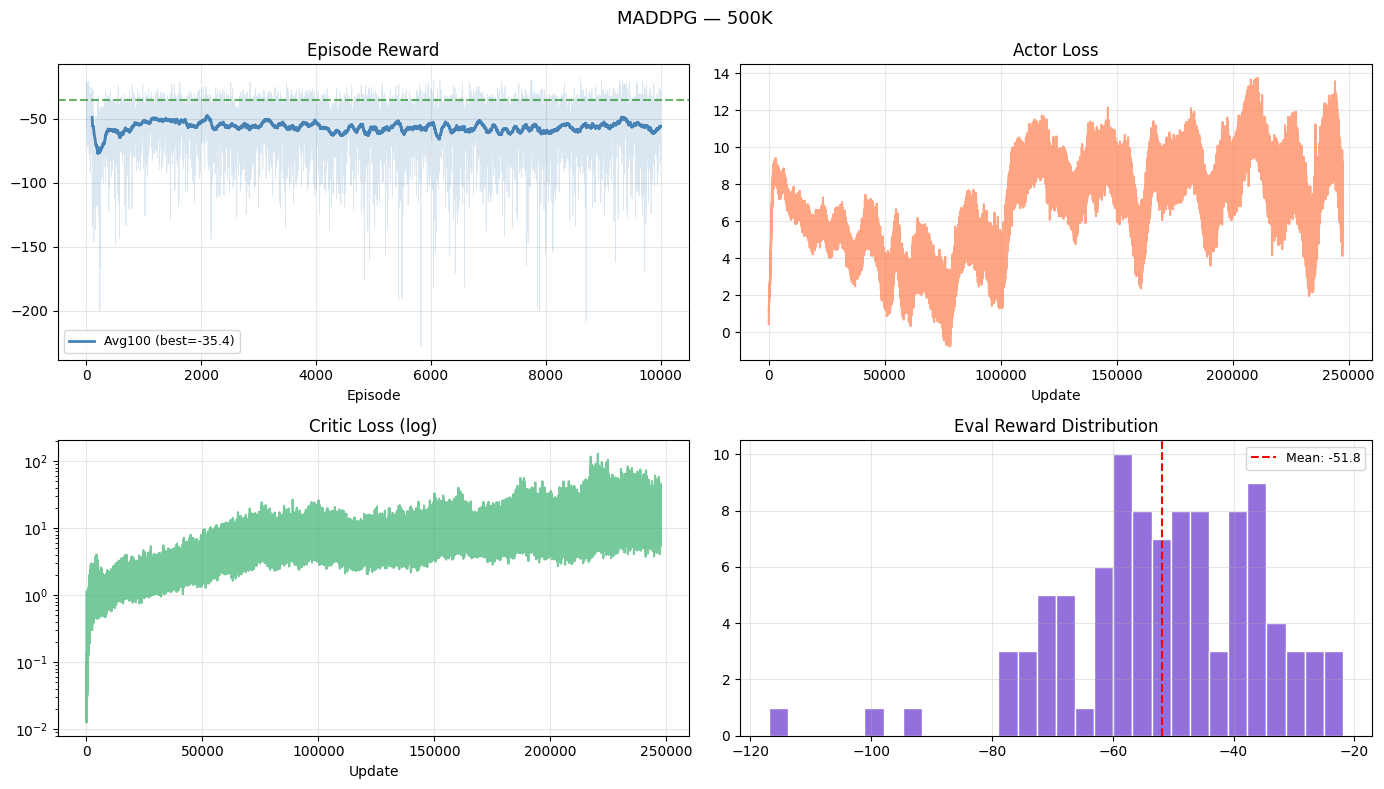

In [20]:
# CELL 21 — Training Curves
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("MADDPG — 500K", fontsize=13)

ax = axes[0,0]
ax.plot(all_ep_rewards, alpha=0.2, color='steelblue', lw=0.5)
w = 100
if len(all_ep_rewards) >= w:
    ma = np.convolve(all_ep_rewards, np.ones(w)/w, mode='valid')
    ax.plot(range(w-1, len(all_ep_rewards)), ma, color='steelblue', lw=2,
            label=f'Avg100 (best={best_avg100:.1f})')
ax.axhline(best_avg100, color='green', ls='--', alpha=0.6)
ax.set_title("Episode Reward"); ax.set_xlabel("Episode")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[0,1]
if a_loss_hist: ax.plot(a_loss_hist, color='coral', alpha=0.7)
ax.set_title("Actor Loss"); ax.set_xlabel("Update"); ax.grid(True, alpha=0.3)

ax = axes[1,0]
if c_loss_hist: ax.semilogy(np.maximum(c_loss_hist,1e-6), color='mediumseagreen', alpha=0.7)
ax.set_title("Critic Loss (log)"); ax.set_xlabel("Update"); ax.grid(True, alpha=0.3)

ax = axes[1,1]
ax.hist(eval_rews, bins=30, color='mediumpurple', edgecolor='white')
ax.axvline(np.mean(eval_rews), color='red', ls='--',
           label=f'Mean: {np.mean(eval_rews):.1f}')
ax.set_title("Eval Reward Distribution")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/maddpg_200K_curves.png", dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# CELL 22 — Save results (Kaggle version)
# Files are already in /kaggle/working/ — this zips them for easy download
import os, shutil, zipfile

src_dir  = "/kaggle/working"
save_dir = "/kaggle/working/MADDPG_500K_results"
os.makedirs(save_dir, exist_ok=True)

# Copy all model/plot files to results folder
copied = []
for f in sorted(os.listdir(src_dir)):
    if f.endswith(('.pth', '.png', '.pkl')) and f != save_dir:
        src  = os.path.join(src_dir, f)
        dst  = os.path.join(save_dir, f)
        if os.path.isfile(src):
            shutil.copy(src, dst)
            size_kb = os.path.getsize(dst) / 1024
            copied.append(f)
            print(f"  {f:45s} {size_kb:7.1f} KB")

# Create zip for single download
zip_path = "/kaggle/working/MADDPG_500K.zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in copied:
        zf.write(os.path.join(save_dir, f), f)

zip_size = os.path.getsize(zip_path) / (1024*1024)
print(f"\n{'='*58}")
print(f"  Saved {len(copied)} files to {save_dir}")
print(f"  Zip: MADDPG_500K.zip ({zip_size:.1f} MB)")
print(f"{'='*58}")
print("\nTo download:")
print("  Kaggle → right panel → Output tab → MADDPG_500K.zip")
print("  Then upload zip to Google Drive manually")

  actor_0_100000.pth                              289.2 KB
  actor_0_100050.pth                              289.2 KB
  actor_0_200000.pth                              289.2 KB
  actor_0_200050.pth                              289.2 KB
  actor_0_300000.pth                              289.2 KB
  actor_0_300050.pth                              289.2 KB
  actor_0_400000.pth                              289.2 KB
  actor_0_400050.pth                              289.2 KB
  actor_0_50.pth                                  289.1 KB
  actor_0_500000.pth                              289.2 KB
  actor_1_100000.pth                              289.2 KB
  actor_1_100050.pth                              289.2 KB
  actor_1_200000.pth                              289.2 KB
  actor_1_200050.pth                              289.2 KB
  actor_1_300000.pth                              289.2 KB
  actor_1_300050.pth                              289.2 KB
  actor_1_400000.pth                              289.2 

In [22]:
# CELL 23 — Verify output files (run anytime to check)
import os

src_dir = "/kaggle/working"
print("Files in /kaggle/working:")
pth_files = []
for f in sorted(os.listdir(src_dir)):
    if f.endswith(('.pth', '.png', '.zip')):
        size = os.path.getsize(os.path.join(src_dir, f)) / 1024
        pth_files.append(f)
        print(f"  {f:45s} {size:7.1f} KB")
print(f"\nTotal: {len(pth_files)} files")
print("\nTo download: Kaggle → Output tab (right panel) → click download icon")

Files in /kaggle/working:
  MADDPG_500K.zip                               11560.1 KB
  actor_0_100000.pth                              289.2 KB
  actor_0_100050.pth                              289.2 KB
  actor_0_200000.pth                              289.2 KB
  actor_0_200050.pth                              289.2 KB
  actor_0_300000.pth                              289.2 KB
  actor_0_300050.pth                              289.2 KB
  actor_0_400000.pth                              289.2 KB
  actor_0_400050.pth                              289.2 KB
  actor_0_50.pth                                  289.1 KB
  actor_0_500000.pth                              289.2 KB
  actor_1_100000.pth                              289.2 KB
  actor_1_100050.pth                              289.2 KB
  actor_1_200000.pth                              289.2 KB
  actor_1_200050.pth                              289.2 KB
  actor_1_300000.pth                              289.2 KB
  actor_1_300050.pth          